A simple sanity check: 

The estimated bias is close to zero when $y=0$, which confirms the OLS property

In [4]:
using LinearAlgebra
using Random
using Statistics
using Distributions
using Plots
using Revise

includet("ridge-regression.jl")


m = 500
n = 50
beta = [1,-1,2]
d = 3
sigma = 1
Sigma = I(d)
y = 0

bias, var_beta = mc_ridge(m,n,beta,sigma,Sigma,y) 
println("The true beta: ",beta)
println("The estimated bias: ",bias)
println("The estimated Variance: ",var_beta)





The true beta: [1, -1, 2]
The estimated bias: [-0.008342017123344703, 0.007648148691329015, 0.0031307917267717755]
The estimated Variance: [0.02219134464866915, 0.020237344577381654, 0.02242524701096521]


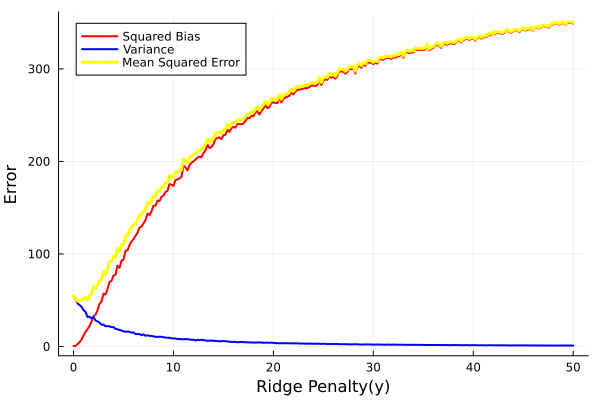

In [5]:
# 2.  bias / Variance trade-off plots
n= 200
d =20
m =100
sigma = 4
beta = randn(d)*5

rank_k = 2
A= randn(d,rank_k)
Sigma = A*A' +0.03*I
ytotal = 0:0.2:50

bias_square = []
variances = []
mses = []

for y in ytotal
    bias_vec,var_vec = mc_ridge(m,n,beta,sigma,Sigma,y)
    ssbias = sum(bias_vec.^2)
    ttvar =sum(var_vec)
    push!(bias_square,ssbias) 
    push!(variances,ttvar)
    push!(mses,ssbias+ttvar)
end

p = plot(ytotal,bias_square,label="Squared Bias",color =:red,lw =2)
plot!(p,ytotal,variances,label="Variance",color =:blue,lw =2)
plot!(p,ytotal,mses,label="Mean Squared Error",color =:yellow,lw =3)

xlabel!("Ridge Penalty(y)") 
ylabel!("Error")
display(p)

As the Ridge penalty increases, we observe a trade-off: the Squared Bias increases while the Variance decreases. 

The total MSE reaches its minimum point at an intermediate level of y.